# Задание 1. Реализация Apriori

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [2]:
import itertools
from collections import defaultdict, Counter
from typing import List, Set, Tuple, Dict, Optional, Any

def apriori(transactions: List[Set], min_support: float) -> Dict[Tuple, float]:
    """
    Реализация алгоритма Apriori.

    Параметры:
        transactions (List[Set]): список транзакций, каждая транзакция — множество уникальных элементов.
        min_support (float): минимальная поддержка (доля от общего числа транзакций).

    Возвращает:
        Dict[Tuple, float]: словарь {itemset_tuple: support_value},
        где itemset_tuple — отсортированный кортеж элементов,
        support_value — доля транзакций, содержащих данный набор.
    """
    n = len(transactions)
    min_count = min_support * n
    if min_count < 1:
        min_count = 1
    else:
        min_count = int(min_count)
    
    # Частые 1-элементы
    item_counts = Counter()
    for trans in transactions:
        item_counts.update(trans)
    freq_itemsets = {(item,): cnt/n for item, cnt in item_counts.items() if cnt >= min_count}
    
    if not freq_itemsets:
        return {}
    
    # Переводим транзакции в frozenset для быстрой проверки подмножества
    trans_sets = [frozenset(t) for t in transactions]
    prev_itemsets = list(freq_itemsets.keys())
    k = 2
    
    while prev_itemsets:
        freq_set_lookup = {frozenset(itemset): True for itemset in prev_itemsets}
        
        candidates_sets = apriori_gen(prev_itemsets, freq_set_lookup, k)
        if not candidates_sets:
            break
        
        candidates_fs = [frozenset(cand) for cand in candidates_sets]
        
        # Подсчёт поддержки
        support_counts = Counter()
        for trans in trans_sets:
            for cand in candidates_fs:
                if cand.issubset(trans):
                    support_counts[cand] += 1
        
        # Фильтрация и добавление новых частых
        new_freq = {}
        for cand, cnt in support_counts.items():
            if cnt >= min_count:
                itemset_tuple = tuple(sorted(cand))
                new_freq[itemset_tuple] = cnt / n
        
        if not new_freq:
            break
        
        freq_itemsets.update(new_freq)
        prev_itemsets = list(new_freq.keys())
        k += 1
    
    return freq_itemsets


def apriori_gen(prev_itemsets: List[Tuple], freq_set_lookup: Dict[frozenset, bool], k: int) -> List[Set]:
    """
    Генерация кандидатов длины k из частых наборов длины k-1.
    """
    candidates = []
    n = len(prev_itemsets)
    for i in range(n):
        for j in range(i + 1, n):
            # Объединяем два (k-1)-набора
            set1 = set(prev_itemsets[i])
            set2 = set(prev_itemsets[j])
            
            list1 = sorted(set1)
            list2 = sorted(set2)
            if list1[:k-2] == list2[:k-2]:
                # Добавляем различающийся элемент
                new_cand_set = set1 | set2
                if len(new_cand_set) == k:
                    subsets_ok = True
                    for sub in itertools.combinations(new_cand_set, k-1):
                        if frozenset(sub) not in freq_set_lookup:
                            subsets_ok = False
                            break
                    if subsets_ok:
                        candidates.append(new_cand_set)
    return candidates


def generate_rules(
    frequent_itemsets: Dict[Tuple, float],
    min_confidence: float,
    min_lift: float = 1.0,
    max_antecedent_len: Optional[int] = None,
    max_consequent_len: Optional[int] = None
) -> List[Tuple[Tuple, Tuple, float, float, float, float, float]]:
    """
    Генерация ассоциативных правил из частых наборов.

    Параметры:
        frequent_itemsets (Dict[Tuple, float]): словарь частых наборов {itemset: support}.
        min_confidence (float): минимальная достоверность.
        min_lift (float): минимальный lift (по умолчанию 1.0).
        max_antecedent_len (Optional[int]): максимальная длина левой части (антецедента).
        max_consequent_len (Optional[int]): максимальная длина правой части (консеквента).

    Возвращает:
        List[Tuple]: список правил, каждое правило представлено кортежем:
        (antecedent, consequent, support, confidence, lift, conviction, leverage).
        antecedent и consequent — отсортированные кортежи элементов.
    """
    rules = []

    for itemset, support_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        itemset_set = set(itemset)
        # Все непустые собственные подмножества
        for r in range(1, len(itemset)):
            for antecedent in itertools.combinations(itemset, r):
                antecedent = tuple(sorted(antecedent))
                consequent = tuple(sorted(itemset_set - set(antecedent)))

                # Проверка ограничений на длину
                if max_antecedent_len is not None and len(antecedent) > max_antecedent_len:
                    continue
                if max_consequent_len is not None and len(consequent) > max_consequent_len:
                    continue

                support_x = frequent_itemsets.get(antecedent, 0.0)
                if support_x == 0.0:
                    continue
                support_y = frequent_itemsets.get(consequent, 0.0)

                confidence = support_xy / support_x
                if confidence < min_confidence:
                    continue

                lift = confidence / support_y if support_y > 0 else float('inf')
                if lift < min_lift:
                    continue

                conviction = (1 - support_y) / (1 - confidence) if confidence < 1 else float('inf')
                leverage = support_xy - support_x * support_y

                rules.append((antecedent, consequent, support_xy, confidence, lift, conviction, leverage))

    return rules

Данный пункт реализует классический алгоритм Apriori для поиска частых наборов и генерации ассоциативных правил. Apriori основан на том, что все подмножества частого набора также являются частыми. Алгоритм итеративно строит кандидаты длины k из частых наборов длины k-1, отсекая заведомо неперспективные комбинации через проверку всех (k-1)-подмножеств (функция apriori_gen). Поддержка кандидатов подсчитывается прямым перебором транзакций, преобразованных во frozenset для ускорения проверки вложенности функцией issubset.

Для ускорения работы использованы несколько оптимизаций: транзакции хранятся как frozenset, частые наборы предыдущей итерации помещаются в dict для поиска за O(1), а генерация правил вынесена в отдельную функцию, которая для каждого частого набора перебирает все разбиения на антецедент и консеквент, вычисляя confidence, lift, conviction и leverage. Функция generate_rules также поддерживает фильтрацию по максимальной длине левой и правой части.

# Задание 2. Реализация FP‑Growth

In [13]:
class FPNode:
    """
    Узел FP-дерева.
    """
    __slots__ = ('item', 'count', 'parent', 'children', 'node_link')
    def __init__(self, item, parent=None):
        self.item = item          # элемент (целое или строка)
        self.count = 1            # счётчик
        self.parent = parent      # родительский узел
        self.children = {}        # дочерние узлы {item: FPNode}
        self.node_link = None     # ссылка на следующий узел с таким же item


def build_fptree(transactions: List[Set], min_count: int):
    """
    Построение FP-дерева и заголовочной таблицы.

    Параметры:
        transactions (List[Set]): список транзакций.
        min_count (int): минимальная абсолютная частота элемента.

    Возвращает:
        root (FPNode): корень дерева.
        header_table (Dict): {item: первый_узел} для элементов, прошедших фильтрацию.
    """
    # Подсчёт частот всех элементов
    freq = Counter()
    for trans in transactions:
        freq.update(trans)

    # Отфильтровываем редкие элементы и сортируем по убыванию частоты
    valid_items = {item for item, cnt in freq.items() if cnt >= min_count}
    if not valid_items:
        return None, None
    order = sorted(valid_items, key=lambda x: (-freq[x], x))
    rank = {item: idx for idx, item in enumerate(order)} 

    # Заголовочная таблица
    header_table = {}

    root = FPNode(None)

    for trans in transactions:
        # Отбираем и сортируем элементы транзакции согласно глобальному порядку
        filtered = [item for item in trans if item in valid_items]
        filtered.sort(key=rank.get)
        if not filtered:
            continue

        # Вставка в дерево
        cur_node = root
        for item in filtered:
            if item in cur_node.children:
                cur_node.children[item].count += 1
                cur_node = cur_node.children[item]
            else:
                new_node = FPNode(item, parent=cur_node)
                cur_node.children[item] = new_node
                cur_node = new_node
                # Добавляем в заголовочную таблицу
                if item not in header_table:
                    header_table[item] = new_node
                else:
                    # Проходим по ссылкам до конца
                    last = header_table[item]
                    while last.node_link is not None:
                        last = last.node_link
                    last.node_link = new_node

    return root, header_table


def fpgrowth(tree: FPNode, header_table: Dict, min_count: int,
             prefix: List, frequent_itemsets: Dict[Tuple, float], n_trans: int):
    """
    Рекурсивный рост паттернов (FP-Growth).

    Параметры:
        tree (FPNode): корень FP-дерева.
        header_table (Dict): заголовочная таблица.
        min_count (int): минимальная абсолютная частота.
        prefix (List): текущий префикс (список элементов, начиная с самого частого).
        frequent_itemsets (Dict): накапливаемый словарь частых наборов.
        n_trans (int): общее количество транзакций (для пересчёта поддержки в доли).
    """
    for item, first_node in sorted(header_table.items(), key=lambda x: x[0]):
        # Поддержка паттерна = сумма count по всем узлам с данным item
        support_count = 0
        node = first_node
        while node:
            support_count += node.count
            node = node.node_link
        if support_count < min_count:
            continue

        new_prefix = [item] + prefix
        itemset = tuple(sorted(new_prefix))
        frequent_itemsets[itemset] = support_count / n_trans

        # Построение условного FP-дерева
        conditional_patterns = defaultdict(int)   # {path_tuple: count}
        node = first_node
        while node:
            # Поднимаемся по родителям до корня, собираем путь не включая изначальный item
            path = []
            cur = node.parent
            while cur and cur.item is not None:
                path.append(cur.item)
                cur = cur.parent
            if path:
                # разворачиваем путь чтобы он шел от корня к листу
                path.reverse()
                conditional_patterns[tuple(path)] += node.count
            node = node.node_link

        # Строим новое дерево из условных паттернов
        # Транзакции: каждая условная транзакция повторяется соответствующее число раз
        cond_transactions = []
        for path, cnt in conditional_patterns.items():
            cond_transactions.extend([set(path)] * cnt)

        if not cond_transactions:
            continue

        cond_root, cond_header = build_fptree(cond_transactions, min_count)
        if cond_header:
            fpgrowth(cond_root, cond_header, min_count, new_prefix, frequent_itemsets, n_trans)


def apriori_fp(transactions: List[Set], min_support: float) -> Dict[Tuple, float]:
    """
    Функция для FP-Growth, возвращающая словарь частых наборов (аналогично apriori).

    Параметры:
        transactions (List[Set]): список транзакций.
        min_support (float): минимальная поддержка (доля).

    Возвращает:
        Dict[Tuple, float]: {itemset_tuple: support_value}.
    """
    n = len(transactions)
    min_count = min_support * n
    if min_count < 1:
        min_count = 1
    else:
        min_count = int(min_count)

    # Построение дерева
    root, header_table = build_fptree(transactions, min_count)
    if root is None:
        return {}

    frequent_itemsets = {}
    fpgrowth(root, header_table, min_count, [], frequent_itemsets, n)
    return frequent_itemsets

def generate_rules_fp(frequent_itemsets: Dict[Tuple, float], min_confidence: float,
                      min_lift: float = 1.0, max_antecedent_len: Optional[int] = None,
                      max_consequent_len: Optional[int] = None) -> List[Tuple]:
    """
    Синоним generate_rules
    """
    return generate_rules(frequent_itemsets, min_confidence, min_lift, max_antecedent_len, max_consequent_len)

Данный пункт реализует алгоритм FP-Growth (Frequent Pattern Growth), который отличается от Apriori отсутствием генерации кандидатов. Вместо многократного сканирования базы данных, алгоритм строит FP-дерево, сжимающее исходные транзакции с сохранением информации о частоте элементов. Класс FPNode определяет структуру узла дерева, хранящую элемент, счётчик, ссылки на родителя, детей и горизонтальные связи node_link для быстрого доступа к одинаковым элементам.

Построение дерева начинается с фильтрации редких элементов и сортировки оставшихся по убыванию частоты. Каждая транзакция вставляется в дерево как путь, где общие префиксы сливаются, увеличивая счётчики. Горизонтальные ссылки объединяют все узлы с одинаковым элементом в связный список через заголовочную таблицу. Рекурсивная функция fpgrowth обходит заголовочную таблицу, для каждого элемента собирает условные паттерны (пути до корня), строит условное FP-дерево и рекурсивно извлекает частые наборы. Такой подход позволяет найти все частые наборы за два прохода по данным, что даёт большой плюс к производительности по сравнению с Apriori.

# Задание 3. Выбор и загрузка реального датасета

C:\Users\Илья\AppData\Local\Temp\ipykernel_12744\3805918548.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transactions = df.groupby('InvoiceNo')['Description'].apply(lambda x: list(set(x))).tolist()


Количество транзакций: 25,900
Количество уникальных товаров: 4,026
Средняя длина транзакции: 20.05

Топ-10 товаров по частоте встречаемости:
  WHITE HANGING HEART T-LIGHT HOLDER      : 2256 (8.7%)
  JUMBO BAG RED RETROSPOT                 : 2089 (8.1%)
  REGENCY CAKESTAND 3 TIER                : 1988 (7.7%)
  PARTY BUNTING                           : 1685 (6.5%)
  LUNCH BAG RED RETROSPOT                 : 1564 (6.0%)
  ASSORTED COLOUR BIRD ORNAMENT           : 1455 (5.6%)
  SET OF 3 CAKE TINS PANTRY DESIGN        : 1385 (5.3%)
  PACK OF 72 RETROSPOT CAKE CASES         : 1320 (5.1%)
  LUNCH BAG  BLACK SKULL.                 : 1273 (4.9%)
  NATURAL SLATE HEART CHALKBOARD          : 1249 (4.8%)


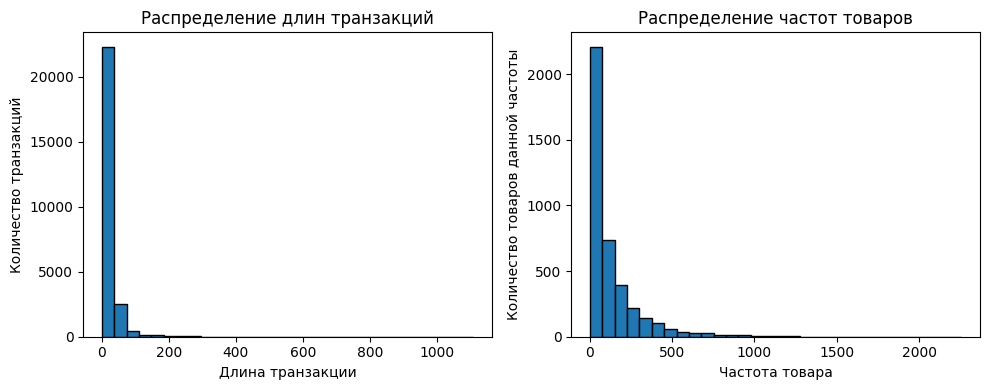

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Online Retail.csv', sep=';')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d.%m.%Y %H:%M', errors='coerce')
df['UnitPrice'] = df['UnitPrice'].str.replace(',', '.').astype(float)
df['CustomerID'] = df['CustomerID'].astype('Int64')
df['InvoiceNo'] = df['InvoiceNo'].astype('category')
df['StockCode'] = df['StockCode'].astype('category')
df['Country'] = df['Country'].astype('category')

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['UnitPrice'] > 0) & (df['Quantity'] > 0)]
upper_bound_price = df['UnitPrice'].quantile(0.99)
upper_bound_quantity = df['Quantity'].quantile(0.99)
df['UnitPrice'] = np.where(df['UnitPrice'] > upper_bound_price, upper_bound_price, df['UnitPrice'])
df['Quantity'] = np.where(df['Quantity'] > upper_bound_quantity, upper_bound_quantity, df['Quantity'])

# Группировка по корзинам (InvoiceNo)
transactions = df.groupby('InvoiceNo')['Description'].apply(lambda x: list(set(x))).tolist()
transactions = [set(t) for t in transactions]

print(f"Количество транзакций: {len(transactions):,}")

all_items = set()
for t in transactions:
    all_items.update(t)
print(f"Количество уникальных товаров: {len(all_items):,}")

avg_len = sum(len(t) for t in transactions) / len(transactions)
print(f"Средняя длина транзакции: {avg_len:.2f}")

item_counts = Counter()
for t in transactions:
    item_counts.update(t)
print("\nТоп-10 товаров по частоте встречаемости:")
for item, count in item_counts.most_common(10):
    print(f"  {item[:40]:40s}: {count} ({count/len(transactions)*100:.1f}%)")

import matplotlib.pyplot as plt

lengths = [len(t) for t in transactions]
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(lengths, bins=30, edgecolor='black')
plt.xlabel('Длина транзакции')
plt.ylabel('Количество транзакций')
plt.title('Распределение длин транзакций')

plt.subplot(1, 2, 2)
freqs = list(item_counts.values())
plt.hist(freqs, bins=30, edgecolor='black')
plt.xlabel('Частота товара')
plt.ylabel('Количество товаров данной частоты')
plt.title('Распределение частот товаров')

plt.tight_layout()
plt.show()

В данном пункте выполняется загрузка и предобработка данных интернет-магазина из Великобритании. Исходный датасет содержит 541909 строк с информацией о покупках за период декабрь 2010 – декабрь 2011. Предобработка включает: преобразование типов данных, удаление возвратов, фильтрацию отрицательных цен и количеств, а также винзоризацию по 99-м перцентилю. После очистки выполняется группировка по корзинам (по InvoiceNo): каждая транзакция формируется как множество уникальных товаров (по Description), что даёт 25900 корзин.

# Задание 4. Эксперименты с параметрами и поиск правил

Apriori:

--- min_support = 0.01 ---
Время поиска частых наборов: 144.44 сек
Частых наборов: 1021

  min_confidence = 0.5: 361 правил
Топ-10 по LIFT (min_conf=0.5):
1. {'REGENCY TEA PLATE GREEN '} -> {'REGENCY TEA PLATE PINK'} | lift=61.96
2. {'REGENCY TEA PLATE PINK'} -> {'REGENCY TEA PLATE GREEN '} | lift=61.96
3. {'REGENCY TEA PLATE PINK'} -> {'REGENCY TEA PLATE ROSES '} | lift=51.33
4. {'REGENCY TEA PLATE ROSES '} -> {'REGENCY TEA PLATE PINK'} | lift=51.33
5. {'REGENCY TEA PLATE GREEN '} -> {'REGENCY TEA PLATE ROSES '} | lift=48.73
6. {'REGENCY TEA PLATE ROSES '} -> {'REGENCY TEA PLATE GREEN '} | lift=48.73
7. {"POPPY'S PLAYHOUSE BEDROOM "} -> {"POPPY'S PLAYHOUSE LIVINGROOM "} | lift=48.54
8. {"POPPY'S PLAYHOUSE LIVINGROOM "} -> {"POPPY'S PLAYHOUSE BEDROOM "} | lift=48.54
9. {"POPPY'S PLAYHOUSE KITCHEN"} -> {"POPPY'S PLAYHOUSE LIVINGROOM "} | lift=47.45
10. {"POPPY'S PLAYHOUSE LIVINGROOM "} -> {"POPPY'S PLAYHOUSE KITCHEN"} | lift=47.45
Топ-10 по CONFIDENCE (min_conf=0.5):
1. {'REGE

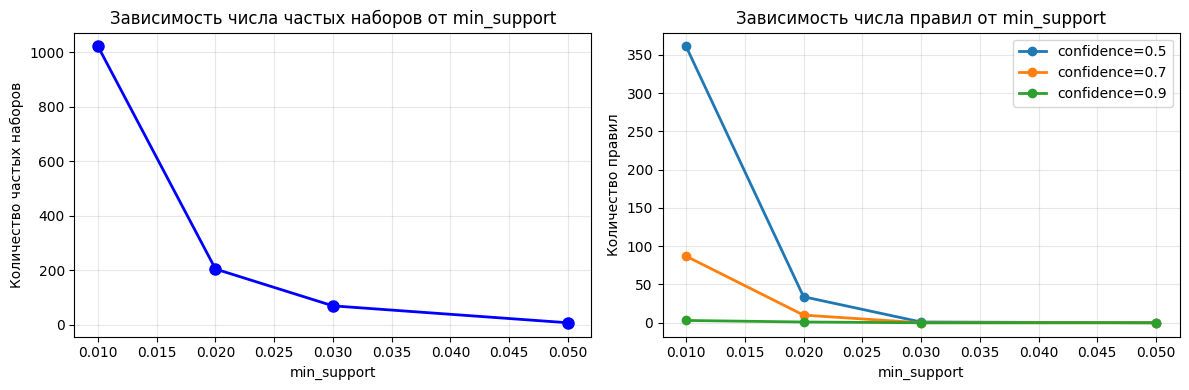

Статистика
min_sup    min_conf   частые наборы   правила   
--------------------------------------------------
0.010      0.5        1021            361       
0.010      0.7        1021            87        
0.010      0.9        1021            3         
0.020      0.5        205             34        
0.020      0.7        205             10        
0.020      0.9        205             1         
0.030      0.5        70              1         
0.030      0.7        70              0         
0.030      0.9        70              0         
0.050      0.5        8               0         
0.050      0.7        8               0         
0.050      0.9        8               0         


In [7]:
import time
min_supports = [0.01, 0.02, 0.03, 0.05]
min_confidences = [0.5, 0.7, 0.9]

results_summary = []

print("Apriori:")

for min_sup in min_supports:
    print(f"\n--- min_support = {min_sup} ---")
    start_time = time.time()
    
    # Поиск частых наборов
    freq_itemsets = apriori(transactions, min_sup)
    apriori_time = time.time() - start_time
    print(f"Время поиска частых наборов: {apriori_time:.2f} сек")
    print(f"Частых наборов: {len(freq_itemsets)}")
    
    for min_conf in min_confidences:
        rules = generate_rules(freq_itemsets, min_conf, min_lift=1.0)
        print(f"\n  min_confidence = {min_conf}: {len(rules)} правил")
        
        top_lift = sorted(rules, key=lambda x: x[4], reverse=True)[:10]
        print(f"Топ-10 по LIFT (min_conf={min_conf}):")
        for i, (ant, con, sup, conf, lift, conv, lev) in enumerate(top_lift[:10], 1):
            print(f"{i}. {set(ant)} -> {set(con)} | lift={lift:.2f}")
        
        top_conf = sorted(rules, key=lambda x: x[3], reverse=True)[:10]
        print(f"Топ-10 по CONFIDENCE (min_conf={min_conf}):")
        for i, (ant, con, sup, conf, lift, conv, lev) in enumerate(top_conf[:10], 1):
            print(f"{i}. {set(ant)} -> {set(con)} | conf={conf:.3f}")
        
        top_lev = sorted(rules, key=lambda x: x[6], reverse=True)[:10]
        print(f"Топ-10 по LEVERAGE (min_conf={min_conf}):")
        for i, (ant, con, sup, conf, lift, conv, lev) in enumerate(top_lev[:10], 1):
            print(f"{i}. {set(ant)} -> {set(con)} | lev={lev:.4f}")
        
        results_summary.append({
            'min_support': min_sup,
            'min_confidence': min_conf,
            'n_freq_itemsets': len(freq_itemsets),
            'n_rules': len(rules)
        })

print(f"\nFP-Growth")

for min_sup in min_supports:
    print(f"\n--- min_support = {min_sup} ---")
    start_time = time.time()
    
    # Поиск частых наборов
    freq_itemsets = apriori_fp(transactions, min_sup)
    fp_time = time.time() - start_time
    print(f"Время поиска частых наборов: {fp_time:.2f} сек")
    print(f"Частых наборов: {len(freq_itemsets)}")
    
    for min_conf in min_confidences:
        rules = generate_rules_fp(freq_itemsets, min_conf, min_lift=1.0)
        print(f"  min_confidence = {min_conf}: {len(rules)} правил")

# График зависимости количества частых наборов и правил от min_support
df_results = pd.DataFrame(results_summary)
df_plot = df_results[df_results['min_confidence'] == 0.5]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_plot['min_support'], df_plot['n_freq_itemsets'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('min_support')
axes[0].set_ylabel('Количество частых наборов')
axes[0].set_title('Зависимость числа частых наборов от min_support')
axes[0].grid(True, alpha=0.3)

for min_conf in [0.5, 0.7, 0.9]:
    df_conf = df_results[df_results['min_confidence'] == min_conf]
    axes[1].plot(df_conf['min_support'], df_conf['n_rules'], 'o-', linewidth=2, 
                 markersize=6, label=f'confidence={min_conf}')
axes[1].set_xlabel('min_support')
axes[1].set_ylabel('Количество правил')
axes[1].set_title('Зависимость числа правил от min_support')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Статистика")
print(f"{'min_sup':<10} {'min_conf':<10} {'частые наборы':<15} {'правила':<10}")
print("-" * 50)
for row in results_summary:
    print(f"{row['min_support']:<10.3f} {row['min_confidence']:<10.1f} {row['n_freq_itemsets']:<15} {row['n_rules']:<10}")

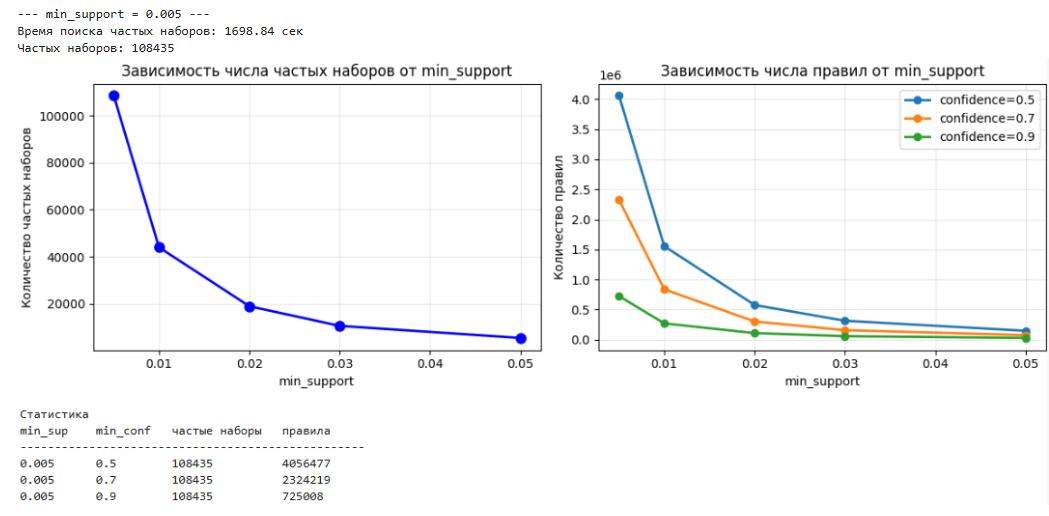

В данном пункте проведены систематические эксперименты с алгоритмами Apriori и FP-Growth на реальных данных. Перебирались значения минимальной поддержки (0.01, 0.02, 0.03, 0.05) и минимальной уверенности (0.5, 0.7, 0.9). Для каждой комбинации выполнялся поиск частых наборов и генерация правил с выводом топ-10 по трём метрикам: lift (во сколько раз вероятность совместной покупки выше случайной), confidence (условная вероятность появления консеквента при антецеденте) и leverage (разность между фактической и ожидаемой поддержкой).

При повышении min_support с 0.01 до 0.05 количество частых наборов падает с 1021 до 8, а правил – с 361 до 0 при confidence=0.5. Выявлены сильные ассоциации внутри коллекций: наборы чашек Regency, игровые домики Poppy's Playhouse, сумки Charlotte и Red Retrospot. При увеличении min_confidence до 0.9 остаются только самые надёжные правила (3 шт.). Графики зависимости наглядно показывают экспоненциальное снижение числа частых наборов и правил с ростом порога поддержки.

# Задание 5. Сравнение производительности Apriori и FP‑Growth

Сравнение Apriori и FP-Growth (min_support = 0.01)


Средняя длина транзакции = 5
  N= 1000... Apriori:   0.24с | FP-Growth:  0.04с | Ускорение:   6.2x
  N= 5000... Apriori:   0.48с | FP-Growth:  0.37с | Ускорение:   1.3x
  N=10000... Apriori:   0.85с | FP-Growth:  0.27с | Ускорение:   3.2x
  N=20000... Apriori:   1.59с | FP-Growth:  0.56с | Ускорение:   2.9x
  N=50000... Apriori:   3.83с | FP-Growth:  1.34с | Ускорение:   2.9x

Средняя длина транзакции = 7
  N= 1000... Apriori:   4.28с | FP-Growth:  0.14с | Ускорение:  29.7x
  N= 5000... Apriori:   5.72с | FP-Growth:  0.54с | Ускорение:  10.7x
  N=10000... Apriori:   7.60с | FP-Growth:  1.08с | Ускорение:   7.0x
  N=20000... Apriori:  10.60с | FP-Growth:  2.33с | Ускорение:   4.6x
  N=50000... Apriori:  21.28с | FP-Growth:  5.23с | Ускорение:   4.1x

Средняя длина транзакции = 10
  N= 1000... Apriori: 390.17с | FP-Growth:  1.06с | Ускорение: 369.6x
  N= 5000... Apriori: 240.39с | FP-Growth:  3.54с | Ускорение:  67.8x
  N=10000... Apri

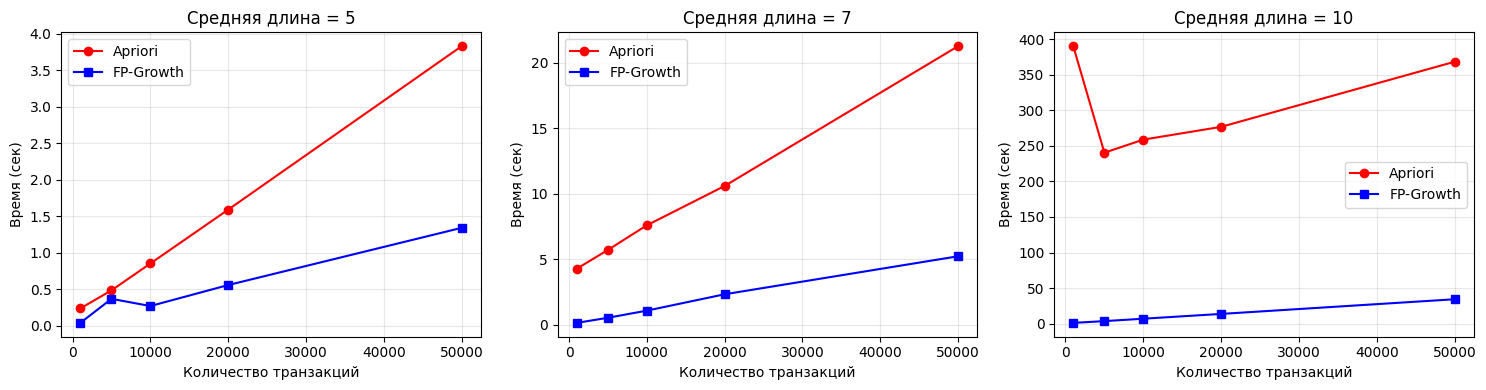

In [10]:
import random

def generate_synthetic_transactions(n_trans, avg_len, n_items=500, seed=42):
    """Генерация синтетических транзакций (Zipf-распределение частот)."""
    random.seed(seed)
    np.random.seed(seed)
    item_probs = np.random.zipf(1.5, n_items)
    item_probs = item_probs / item_probs.sum()
    transactions = []
    for _ in range(n_trans):
        length = max(1, np.random.poisson(avg_len))
        items = set(np.random.choice(n_items, size=length, replace=False, p=item_probs))
        transactions.append(items)
    return transactions

n_transactions = [1000, 5000, 10000, 20000, 50000]
avg_lengths = [5, 7, 10]
min_support = 0.01

results = {avg_len: {'apriori': [], 'fpgrowth': []} for avg_len in avg_lengths}

print(f"Сравнение Apriori и FP-Growth (min_support = 0.01)\n")

for avg_len in avg_lengths:
    print(f"\nСредняя длина транзакции = {avg_len}")
    for n in n_transactions:
        print(f"  N={n:5d}...", end=" ")
        trans = generate_synthetic_transactions(n, avg_len, seed=42)
        
        start = time.time()
        freq_ap = apriori(trans, min_support)
        t_ap = time.time() - start
        
        start = time.time()
        freq_fp = apriori_fp(trans, min_support)
        t_fp = time.time() - start
        
        results[avg_len]['apriori'].append(t_ap)
        results[avg_len]['fpgrowth'].append(t_fp)
        print(f"Apriori: {t_ap:6.2f}с | FP-Growth: {t_fp:5.2f}с | Ускорение: {t_ap/t_fp:5.1f}x")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, avg_len in enumerate(avg_lengths):
    ax = axes[i]
    ax.plot(n_transactions, results[avg_len]['apriori'], 'ro-', label='Apriori')
    ax.plot(n_transactions, results[avg_len]['fpgrowth'], 'bs-', label='FP-Growth')
    ax.set_xlabel('Количество транзакций')
    ax.set_ylabel('Время (сек)')
    ax.set_title(f'Средняя длина = {avg_len}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Полученные различия в производительности Apriori и FP‑Growth объясняются их вычислительной сложностью.  
Apriori на каждом шаге генерирует и проверяет все кандидатные наборы, что при малой длине транзакций (5) не дает слишком большого прироста к числу операций (ускорение FP‑Growth до 6×), но уже при длине 7 число комбинаций резко возрастает, а при длине 10 происходит комбинаторный взрыв – время Apriori достигает сотен секунд даже на 1000 транзакциях. При этом Apriori вынужден многократно сканировать весь набор данных.  
FP‑Growth строит FP‑дерево за два прохода и рекурсивно извлекает частые наборы без генерации кандидатов, обеспечивая практически линейную сложность по числу транзакций и длине. Этим объясняется стабильно малое время работы FP‑Growth (1–35 секунд) и его ускорение от 4 до 370 раз в зависимости от длины транзакции.

# Задание 6. Визуализация ассоциативных правил

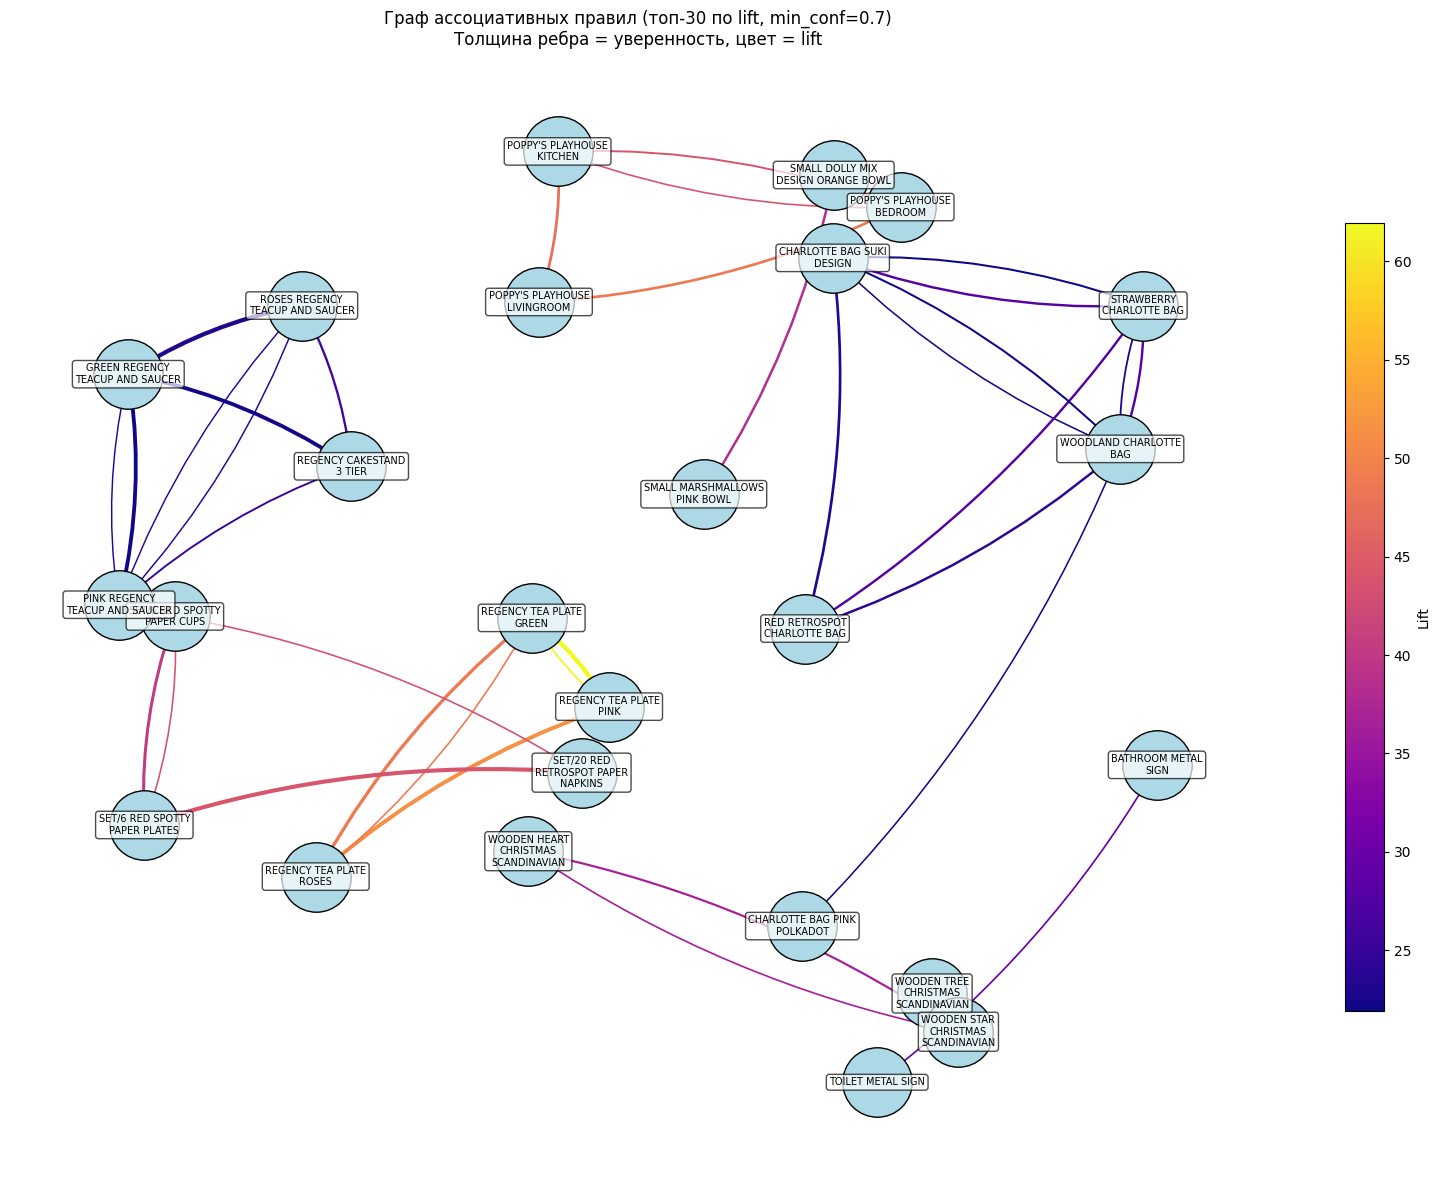

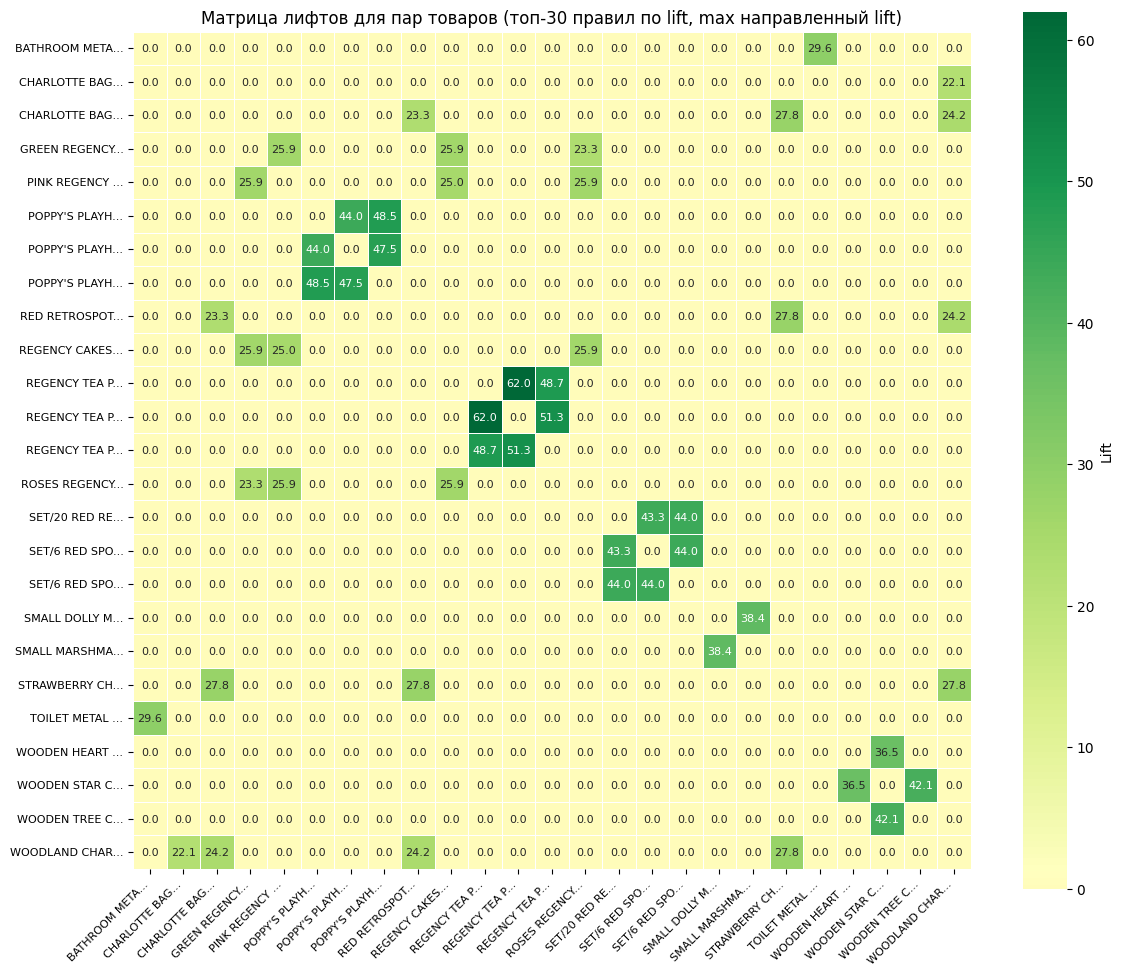

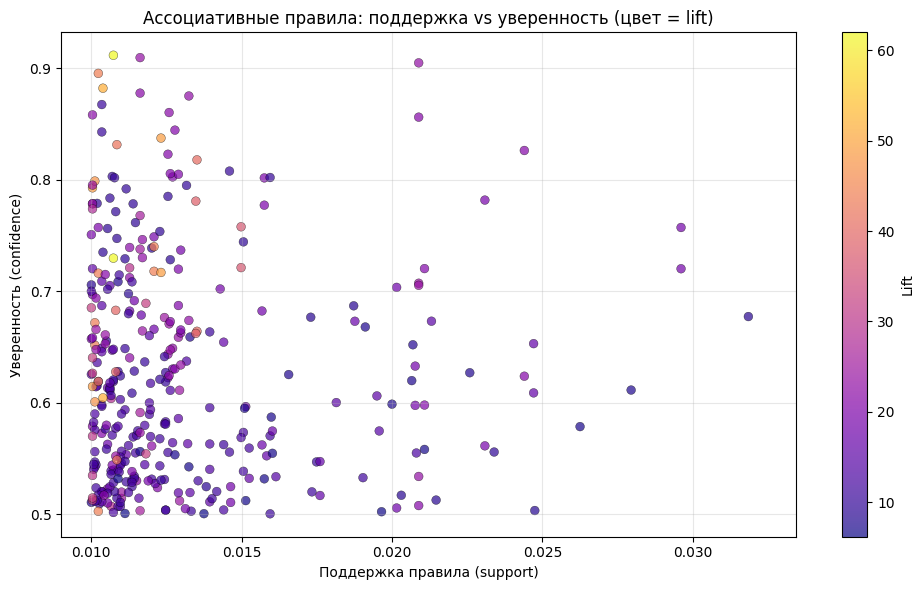

Правила с наибольшим Support
1. {'JUMBO BAG PINK POLKADOT'} → {'JUMBO BAG RED RETROSPOT'}
   support = 0.0319, confidence = 0.677, lift = 8.4

2. {'GREEN REGENCY TEACUP AND SAUCER'} → {'ROSES REGENCY TEACUP AND SAUCER '}
   support = 0.0296, confidence = 0.757, lift = 18.4

3. {'ROSES REGENCY TEACUP AND SAUCER '} → {'GREEN REGENCY TEACUP AND SAUCER'}
   support = 0.0296, confidence = 0.720, lift = 18.4

4. {'JUMBO STORAGE BAG SUKI'} → {'JUMBO BAG RED RETROSPOT'}
   support = 0.0280, confidence = 0.611, lift = 7.6

Правила с наибольшим confidence
1. {'REGENCY TEA PLATE PINK'} → {'REGENCY TEA PLATE GREEN '}
   support = 0.0107, confidence = 0.911, lift = 62.0

2. {'PINK REGENCY TEACUP AND SAUCER', 'REGENCY CAKESTAND 3 TIER', 'ROSES REGENCY TEACUP AND SAUCER '} → {'GREEN REGENCY TEACUP AND SAUCER'}
   support = 0.0116, confidence = 0.909, lift = 23.3

3. {'PINK REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER '} → {'GREEN REGENCY TEACUP AND SAUCER'}
   support = 0.0209, confid

In [55]:
import networkx as nx
import textwrap

freq_itemsets = apriori_fp(transactions, min_support=0.01)
rules = generate_rules(freq_itemsets, min_confidence=0.7, min_lift=1.0)
top_rules = sorted(rules, key=lambda x: x[4], reverse=True)[:30]

G = nx.DiGraph()
for ant, con, sup, conf, lift, conv, lev in top_rules:
    for a in ant:
        for c in con:
            G.add_edge(a, c, weight=lift, confidence=conf)

def wrap_label(text, width=15):
    return "\n".join(textwrap.wrap(text, width))

labels = {node: wrap_label(node, width=18) for node in G.nodes()}

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='lightblue', edgecolors='black')

edges = G.edges()
lifts = [G[u][v]['weight'] for u, v in edges]
confidences = [G[u][v]['confidence'] for u, v in edges]

norm_lift = plt.Normalize(min(lifts), max(lifts))
edge_colors = plt.cm.plasma(norm_lift(lifts))
edge_widths = [(c - 0.7)/0.3 * 3 + 1 for c in confidences]

nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, 
                       arrows=True, arrowstyle='->', arrowsize=12, connectionstyle='arc3,rad=0.1')

for node, (x, y) in pos.items():
    plt.text(x, y, labels[node], ha='center', va='center', fontsize=7,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm_lift)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.7)
cbar.set_label('Lift')

plt.title('Граф ассоциативных правил (топ-30 по lift, min_conf=0.7)\nТолщина ребра = уверенность, цвет = lift', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

items = set()
for ant, con, _, _, _, _, _ in top_rules:
    items.update(ant)
    items.update(con)
items = sorted(items) 

n = len(items)
lift_matrix = np.zeros((n, n))
item_to_idx = {item: i for i, item in enumerate(items)}

for ant, con, _, _, lift, _, _ in top_rules:
    for a in ant:
        for c in con:
            i = item_to_idx[a]
            j = item_to_idx[c]
            current = lift_matrix[i, j]
            lift_matrix[i, j] = max(current, lift)
            lift_matrix[j, i] = max(lift_matrix[j, i], lift)

df_lift = pd.DataFrame(lift_matrix, index=items, columns=items)

def shorten(name, max_len=14):
    return name[:max_len-3] + '...' if len(name) > max_len else name

short_labels = [shorten(item, 16) for item in items]

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df_lift, dtype=bool), k=1)
ax = sns.heatmap(df_lift, 
                 annot=True, 
                 fmt='.1f',
                 cmap='RdYlGn',
                 center=1,
                 square=True,
                 cbar_kws={'label': 'Lift'},
                 xticklabels=short_labels,
                 yticklabels=short_labels,
                 linewidths=0.5,
                 annot_kws={'size': 8})
plt.title('Матрица лифтов для пар товаров (топ-30 правил по lift, max направленный lift)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

freq_itemsets = apriori_fp(transactions, min_support=0.01)
rules = generate_rules(freq_itemsets, min_confidence=0.5, min_lift=1.0)

supports = [r[2] for r in rules]
confidences = [r[3] for r in rules]
lifts = [r[4] for r in rules]

plt.figure(figsize=(10, 6))
sc = plt.scatter(supports, confidences, c=lifts, cmap='plasma', alpha=0.7, 
                 edgecolors='black', linewidth=0.3, s=40)
plt.colorbar(sc, label='Lift')
plt.xlabel('Поддержка правила (support)')
plt.ylabel('Уверенность (confidence)')
plt.title('Ассоциативные правила: поддержка vs уверенность (цвет = lift)')
plt.grid(True, alpha=0.3)

min_sup = min(supports)
plt.xlim(left=min_sup * 0.9)
plt.xlim(right=max(supports) * 1.05)

plt.tight_layout()
plt.show()

rules_sorted_by_support = sorted(rules, key=lambda x: x[2], reverse=True)
rules_sorted_by_confidence = sorted(rules, key=lambda x: x[3], reverse=True)

print("Правила с наибольшим Support")
for i in range(4):
    ant, con, sup, conf, lift, conv, lev = rules_sorted_by_support[i]
    print(f"{i+1}. {set(ant)} → {set(con)}")
    print(f"   support = {sup:.4f}, confidence = {conf:.3f}, lift = {lift:.1f}\n")

print("Правила с наибольшим confidence")
for i in range(4):
    ant, con, sup, conf, lift, conv, lev = rules_sorted_by_confidence[i]
    print(f"{i+1}. {set(ant)} → {set(con)}")
    print(f"   support = {sup:.4f}, confidence = {conf:.3f}, lift = {lift:.1f}\n")

Направленный граф отображает топ-30 правил с наибольшим лифтом при min_conf=0.7. Узлы представляют отдельные товары, рёбра направлены от антецедента к консеквенту. Цвет ребра кодирует значение лифта, толщина – уверенность правила. Граф наглядно демонстрирует кластеризацию товаров по тематическим коллекциям. Направления рёбер показывают асимметрию уверенности: например, розовая тарелка чаще ведёт к зелёной (conf=0.911), чем обратно.

Тепловая карта показывает попарные значения лифта для всех товаров, участвующих в топ-30 правилах. Зелёные ячейки соответствуют lift > 1 (положительная ассоциация), желтые - отсутствию ассоциации. Матрица симметрична, так как lift(X→Y) = lift(Y→X).

Каждая точка диаграммы рассеяния соответствует одному ассоциативному правилу при min_sup=0.01 и min_conf=0.5. На оси X – поддержка (доля транзакций с данной комбинацией), на оси Y – уверенность. Цвет точки кодирует лифт. Наблюдается характерное распределение: правила с высокой уверенностью и высоким лифтом сконцентрированы в области низкой поддержки – это нишевые правила для редких товаров. По мере роста поддержки уверенность снижается до 0.5–0.7, а лифт падает до 10–20. Точек в области высокой поддержки (>0.03) мало, что отражает разреженность данных.

# Задание 7. Интерпретация результатов
Анализ ассоциативных правил для интернет-магазина выявил устойчивые паттерны покупок. Наиболее сильные правила (lift > 50) связывают товары из связанных смыслом наборов, например коллекции «Regency»: чайные тарелки и чашки разных цветов (розовый, зелёный, розы). Эти товары часто покупаются вместе, что может быть использовано для рекомендаций или для формирования готовых комплектов со скидкой. Массовые товары (например, цветные сумки-шопперы) формируют правила с умеренным lift (≈8) и поддержкой до 0.03, что указывает на менее тесную, но более частую связь – такие правила подходят для кросс-продаж.

Некоторые правила, даже с высоким лифтом, могут оказаться бесполезными. Например, тривиальные сочетания вроде двух цветов одной модели посуды очевидны для покупателя. Также правила, основанные на редких товарах (например, с участием “REGENCY CAKESTAND 3 TIER”), дают хорошую точность, но охватывают ничтожную долю транзакций – их применение в массовых рекомендациях неэффективно. Тем не менее для персонализированного подхода (например, в момент просмотра редкого товара) такие правила могут быть ценными.
